# Cerberus Compliance SDK — Grand Tour 🐍🔱

Un solo notebook que **explota a fondo** el SDK `cerberus-compliance` v0.6.0 contra el
endpoint live `https://compliance.cerberus.cl/v1`. Cubrimos los 23 recursos del API
público, mostramos gráficos reales, agregaciones, paginación cursorada, búsqueda
semántica, webhooks firmados, y un dashboard final de riesgo regulatorio chileno.

**Stack del notebook**
- `cerberus-compliance==0.5.1` — SDK oficial
- `pandas`, `matplotlib` — análisis y visualización
- `asyncio` — fan-out concurrente sobre el cliente async

**Setup**

```bash
pip install --upgrade "cerberus-compliance==0.6.0" pandas matplotlib
export CERBERUS_API_KEY=ck_live_<your-key>
```

> Necesitás una API key viva apuntando a `compliance.cerberus.cl/v1`.
> El notebook lee `CERBERUS_API_KEY` del entorno y aborta si no está
> seteada — nunca se incrusta una key en el código fuente.

> Las celdas se ejecutan secuencialmente. Cada sección incluye una explicación corta
> antes del código, los resultados crudos del endpoint, y — donde aporta valor — un
> gráfico o tabla resumen.


## 1 · Setup & introspección de la API key

Antes de hacer cualquier llamada de negocio, conviene confirmar a qué apunta la key:
tier, scopes, cuota residual, fecha de expiración. Eso vive en
`/v1/admin/api-keys/me` (scope `*` — siempre disponible).


In [1]:
from __future__ import annotations

import json
import os
from datetime import date, datetime, timedelta
from pprint import pprint

# Hard-fail si la API key no está en el entorno: nunca incrustamos
# secretos en código bajo control de versiones.
assert os.getenv("CERBERUS_API_KEY"), (
    "Set CERBERUS_API_KEY before running this notebook "
    "(e.g. `export CERBERUS_API_KEY=ck_live_…`)."
)

import cerberus_compliance
from cerberus_compliance import CerberusClient, AsyncCerberusClient
print(f"SDK version: {cerberus_compliance.__version__}")


SDK version: 0.6.0


In [2]:
client = CerberusClient()  # base_url = https://compliance.cerberus.cl/v1
me = client.admin_api_keys.me()

print(f"prefix       : {me['key_prefix']}")
print(f"env          : {me['env']}")
print(f"tier         : {me['tier']}")
print(f"expires_at   : {me['expires_at']}")
print(f"last_used    : {me['last_used_at']}")
print(f"scopes ({len(me['scopes'])}):")
for s in me['scopes']:
    print(f"  • {s}")

q = me['quota']; dq = me['daily_quota']
def _fmt(n):
    return "∞ (unlimited)" if n == -1 else f"{n:,}"
print()
print(f"monthly      : consumed={_fmt(q['monthly_consumed'])}  remaining={_fmt(q['monthly_remaining'])}")
print(f"daily        : consumed={_fmt(dq['daily_consumed'])}   remaining={_fmt(dq['daily_remaining'])}")


prefix       : ck_live_d40549b9
env          : live
tier         : enterprise
expires_at   : 2027-04-28T13:21:34.531268Z
last_used    : 2026-04-28T13:53:06.540382Z
scopes (14):
  • kyb:read
  • entities:read
  • sanctions:read
  • regulations:read
  • normativa:read
  • rpsf:read
  • esg:read
  • search:read
  • resolver:read
  • indicadores:read
  • webhooks:read
  • webhooks:write
  • exports:read
  • exports:write

monthly      : consumed=180  remaining=∞ (unlimited)
daily        : consumed=0   remaining=∞ (unlimited)


## 2 · KYB Express — perfil regulatorio agregado en una llamada

`client.kyb.get(rut, include=[...])` es el endpoint estrella: une entidad,
directores actuales, sanciones, hechos esenciales recientes, ownership LEI y
risk score en una sola respuesta. Probémoslo con **Banco de Chile** (RUT 97.004.000-5).


In [3]:
profile = client.kyb.get(
    rut="97004000-5",
    include=["directors", "lei", "hechos_esenciales", "ownership"],
)

print(f"legal_name      : {profile['legal_name']}")
print(f"fantasy_name    : {profile.get('fantasy_name')}")
print(f"rut_canonical   : {profile['rut_canonical']}")
print(f"entity_kind     : {profile['entity_kind']}")
print(f"status          : {profile['status']}")
print(f"size_bucket     : {profile.get('size_bucket')}")
print(f"inscription     : {profile['inscription_date']}  →  {profile.get('cancellation_date') or '(activa)'}")
print(f"LEI             : {profile.get('lei')}")
print()
print(f"risk_score      : {profile['risk_score']} / 100")
print(f"risk_factors    : {profile.get('risk_factors')}")


legal_name      : Banco de Chile SA
fantasy_name    : Banco de Chile
rut_canonical   : 97004000-5
entity_kind     : banco
status          : vigente
size_bucket     : None
inscription     : 1893-10-27  →  (activa)
LEI             : PVVK4N5A7MITLWQJQQ35

risk_score      : 50 / 100
risk_factors    : ['active_sanctions', 'directors_turnover_high', 'historical_sanctions_12m', 'lei_registrada', 'ult_he_routine']


In [4]:
# Directores actuales del directorio
directors = profile.get('directors_current') or []
print(f"Directorio vigente — {len(directors)} miembros")
print("─" * 72)
for d in directors[:10]:
    print(f"  {d.get('cargo','?'):14s}  {d.get('persona_rut','?'):14s}  {d.get('nombre','?'):40s}  desde {d.get('fecha_inicio','?')}")


Directorio vigente — 2 miembros
────────────────────────────────────────────────────────────────────────
  presidente      6.972.382-9     PABLO JOSÉ GRANIFO LAVIN                  desde 2026-04-25
  director        6.972.382-9     PABLO JOSÉ GRANIFO LAVIN                  desde 2026-04-25


In [5]:
# Hechos esenciales recientes
events = profile.get('recent_material_events') or []
print(f"Hechos esenciales recientes ({len(events)}):")
for e in events[:6]:
    when = (e.get('publicacion_at') or '')[:10]
    asunto = (e.get('asunto') or '')[:90]
    print(f"  {when}  {asunto}")


Hechos esenciales recientes (1):
  2026-04-09  Hecho esencial — nombramiento gerente general


## 3 · Portfolio scan asíncrono — 6 emisores en paralelo

Cuando hay que perfilar múltiples entidades, el cliente síncrono es un cuello
de botella. `AsyncCerberusClient` reutiliza un único `httpx.AsyncClient` con
keep-alive, así que `asyncio.gather` despacha N consultas en paralelo con un
solo handshake TLS.


In [6]:
import asyncio

PORTFOLIO = [
    ("97004000-5", "Banco de Chile"),
    ("97036000-K", "Banco Santander"),
    ("96505760-9", "Falabella"),
    ("90320000-6", "Enel Chile"),
    ("91041000-8", "Viña San Pedro Tarapacá"),
    ("99500840-3", "BCI (sociedad)"),
]

async def fetch_one(c, rut, hint):
    try:
        p = await c.kyb.get(rut=rut, include=["directors"])
        return {
            "rut": rut, "hint": hint,
            "legal_name": p.get("legal_name"),
            "kind": p.get("entity_kind"),
            "status": p.get("status"),
            "size": p.get("size_bucket"),
            "risk_score": p.get("risk_score"),
            "n_directors": len(p.get("directors_current") or []),
            "lei": p.get("lei"),
            "ok": True,
        }
    except Exception as e:
        return {"rut": rut, "hint": hint, "ok": False, "err": str(e)[:120]}

async def main():
    async with AsyncCerberusClient() as c:
        return await asyncio.gather(*(fetch_one(c, r, h) for r, h in PORTFOLIO))

# Jupyter ya tiene un loop corriendo → asyncio.run no anida. Usamos el patrón canónico:
import nest_asyncio; nest_asyncio.apply()
results = asyncio.run(main())

import pandas as pd
df = pd.DataFrame(results)
df


,rut,hint,legal_name,kind,status,size,risk_score,n_directors,lei,ok,err
0,97004000-5,Banco de Chile,Banco de Chile SA,banco,vigente,NaN,50.0,2.0,NaN,True,NaN
1,97036000-K,Banco Santander,BANCO SANTANDER-CHILE,banco,vigente,NaN,25.0,2.0,NaN,True,NaN
2,96505760-9,Falabella,Falabella SA,emisor,vigente,ipsa,10.0,9.0,NaN,True,NaN
3,90320000-6,Enel Chile,Enel Chile SA,emisor,vigente,ipsa,15.0,7.0,NaN,True,NaN
4,91041000-8,Viña San Pedro Tarapacá,VIÑA SAN PEDRO TARAPACA S.A.,emisor,vigente,NaN,15.0,5.0,NaN,True,NaN
5,99500840-3,BCI (sociedad),NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,422 Validation error: Request validation faile...


### 3.1 Risk score por emisor — barra horizontal coloreada

`risk_score` está normalizado 0–100 y se calcula server-side combinando: sanciones
activas, antigüedad de inscripción, hechos esenciales relevantes, y match contra
listas internacionales. Banda de color:
- 🟢 0–20 (bajo) · 🟡 21–50 (medio) · 🔴 51–100 (alto)


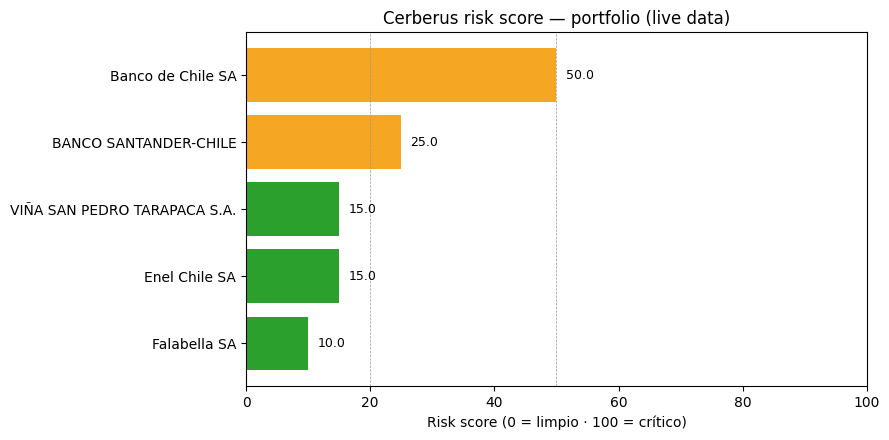

In [7]:
import matplotlib.pyplot as plt

portfolio_ok = df[df["ok"]].copy().sort_values("risk_score")

def _color(score):
    if score is None: return "#999"
    if score <= 20:  return "#2ca02c"   # verde
    if score <= 50:  return "#f5a623"   # ámbar
    return "#d62728"                    # rojo

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(portfolio_ok["legal_name"], portfolio_ok["risk_score"],
               color=[_color(s) for s in portfolio_ok["risk_score"]])
ax.set_xlim(0, 100)
ax.set_xlabel("Risk score (0 = limpio · 100 = crítico)")
ax.set_title("Cerberus risk score — portfolio (live data)")
ax.axvline(20, color="#999", lw=0.5, ls="--")
ax.axvline(50, color="#999", lw=0.5, ls="--")
for b, v in zip(bars, portfolio_ok["risk_score"]):
    ax.text(v + 1.5, b.get_y() + b.get_height()/2, f"{v}", va="center", fontsize=9)
plt.tight_layout(); plt.show()


## 4 · Universo de sanciones CMF — paginación + estadísticas

El endpoint `/sanctions` enumera **todas** las sanciones publicadas por la CMF
(con metadatos: fecha, infracción, multa en UF/CLP, estado: vigente/prescrita/firme).
Aquí leemos los últimos 50 registros y calculamos estadísticas agregadas.


In [8]:
sanctions = client.sanctions.list(limit=50)

print(f"Sanciones recuperadas: {len(sanctions)}")
print()
df_s = pd.DataFrame(sanctions)
df_s["fecha_resolucion"] = pd.to_datetime(df_s["fecha_resolucion"], errors="coerce")
df_s["multa_uf_num"] = pd.to_numeric(df_s["multa_uf"], errors="coerce")

# Estadísticas
print(f"Rango de fechas      : {df_s['fecha_resolucion'].min().date()} → {df_s['fecha_resolucion'].max().date()}")
print(f"Con multa en UF      : {df_s['multa_uf_num'].notna().sum()} / {len(df_s)}")
print(f"Multa total UF       : {df_s['multa_uf_num'].sum():,.0f}")
print(f"Multa máxima UF      : {df_s['multa_uf_num'].max():,.0f}")
print(f"Multa mediana UF     : {df_s['multa_uf_num'].median():,.0f}")
print()
print("Distribución por estado:")
print(df_s["estado"].value_counts().to_string())


Sanciones recuperadas: 50

Rango de fechas      : 2025-07-22 → 2026-04-14
Con multa en UF      : 1 / 50
Multa total UF       : 500
Multa máxima UF      : 500
Multa mediana UF     : 500

Distribución por estado:
estado
prescrita    27
vigente      21
anulada       2


In [9]:
# Top 10 multas por monto en UF
top = df_s.dropna(subset=["multa_uf_num"]).nlargest(10, "multa_uf_num")
top_view = top[["fecha_resolucion", "cmf_resolucion_id", "estado", "multa_uf_num", "infraccion"]].copy()
top_view["infraccion"] = top_view["infraccion"].str.slice(0, 70) + "…"
top_view.columns = ["fecha", "ID resolución", "estado", "UF", "infracción"]
top_view.reset_index(drop=True)


,fecha,ID resolución,estado,UF,infracción
0,2026-01-24,SAN-96655920-9-000,vigente,500.0,Incumplimiento de política de conocimiento del...


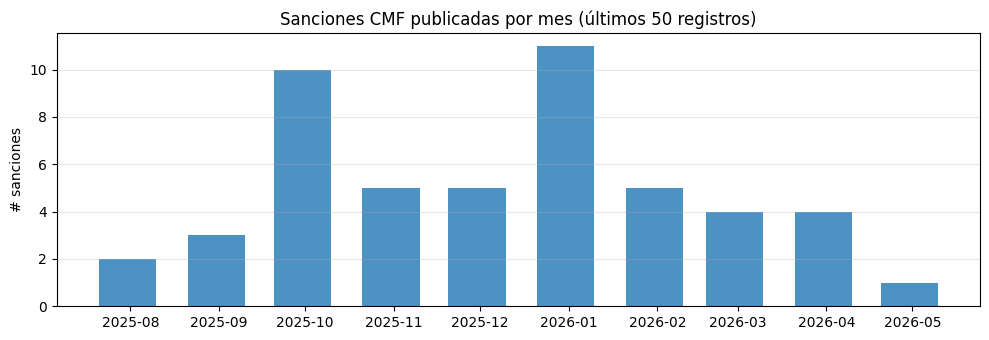

In [10]:
# Sanciones por mes — serie temporal
monthly = (
    df_s.dropna(subset=["fecha_resolucion"])
    .set_index("fecha_resolucion")
    .resample("ME")
    .size()
    .rename("n_sanciones")
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(monthly.index, monthly.values, width=20, color="#1f77b4", alpha=0.8)
ax.set_title("Sanciones CMF publicadas por mes (últimos 50 registros)")
ax.set_ylabel("# sanciones")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 5 · Búsqueda semántica cross-tipo (Bedrock Titan Embeddings)

`POST /v1/search` corre el query embebido contra **todos** los tipos de documento
del API (resoluciones, OPAs, TDC, art12/20, comunicaciones, dictámenes, ESG,
normativa, normativa_consulta, hechos esenciales, RAN capítulos) y devuelve
hits ordenados por similitud coseno. El SDK retorna `SearchResponse` tipado.


In [11]:
from cerberus_compliance import SearchDateRange, SearchFilters

resp = client.search.search(
    query="lavado de activos y financiamiento del terrorismo",
    top_k=8,
)
print(f"query           : {resp.query!r}")
print(f"total escaneado : {resp.total_searched:,} documentos")
print(f"hits devueltos  : {len(resp.hits)}\n")

for i, h in enumerate(resp.hits, 1):
    print(f"[{i}] score={h.score:.3f}  tabla={h.source_table:30s}  tipo={h.tipo_documento}")
    if h.payload:
        snippet = json.dumps(h.payload, ensure_ascii=False, default=str)[:120]
        print(f"     payload: {snippet}…")


query           : 'lavado de activos y financiamiento del terrorismo'
total escaneado : 40 documentos
hits devueltos  : 8

[1] score=0.577  tabla=cmf_ran_capitulos               tipo=ran_capitulo
[2] score=0.339  tabla=cmf_ran_capitulos               tipo=ran_capitulo
[3] score=0.321  tabla=cmf_hechos_esenciales           tipo=hecho_esencial
[4] score=0.321  tabla=cmf_hechos_esenciales           tipo=hecho_esencial
[5] score=0.260  tabla=cmf_art12_transactions          tipo=art12_transaccion
     payload: {"id": "b04148bc-0eb1-41e3-843f-7bba3eca26d7", "emisor_rut": "94270000", "emisor_nombre": "ALMENDRAL S.A.", "persona_rut…
[6] score=0.258  tabla=cmf_art12_transactions          tipo=art12_transaccion
     payload: {"id": "f2544fca-dfaf-4209-86c5-a1b7a1cb8c45", "emisor_rut": "97004000", "emisor_nombre": "BANCO DE CHILE", "persona_rut…
[7] score=0.258  tabla=cmf_opas                        tipo=opa
     payload: {"id": "5c7070cc-8e68-41b2-8d59-53c9648558fc", "numero": "2025030156911", "

In [12]:
# Filtrado por taxonomía — normativa con marco NCG 461, último año
filtered = client.search.search(
    query="ciberseguridad y resiliencia operacional",
    top_k=5,
    filters=SearchFilters(
        tipo_documento=["normativa", "dictamen"],
        date_range=SearchDateRange(
            from_=(date.today() - timedelta(days=365)).isoformat(),
        ),
    ),
)
print(f"Hits filtrados ({len(filtered.hits)}):")
for h in filtered.hits:
    print(f"  {h.score:.3f}  {h.source_table:35s}  ent={h.entity_rut or '—'}")


Hits filtrados (0):


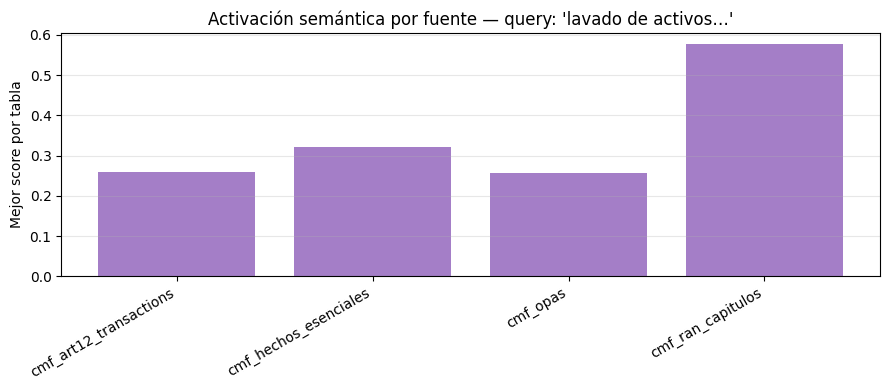

In [13]:
# Score-vs-tipo: ¿qué tablas se activan más fuerte para un query AML?
hits = resp.hits
tables = sorted({h.source_table for h in hits})
best_per_table = {t: max(h.score for h in hits if h.source_table == t) for t in tables}

fig, ax = plt.subplots(figsize=(9, 4))
positions = range(len(tables))
ax.bar(positions, [best_per_table[t] for t in tables], color="#9467bd", alpha=0.85)
ax.set_xticks(positions)
ax.set_xticklabels(tables, rotation=30, ha="right")
ax.set_ylabel("Mejor score por tabla")
ax.set_title("Activación semántica por fuente — query: 'lavado de activos…'")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 6 · Indicadores macro CMF/SBIF (UF, USD, UTM, IPC)

`/v1/indicadores/{name}` devuelve el spot. Si se pasa `from`/`to`, devuelve la
serie completa. Vamos por las cuatro grandes referencias chilenas.


In [14]:
# Spot actual de los cuatro indicadores principales
SPOT = {}
for name in ["uf", "usd", "utm", "ipc"]:
    v = client.indicadores.get(name)
    SPOT[name] = (v["value"], v["date"])
    print(f"  {name.upper():4s}  {float(v['value']):>14,.4f}   ({v['date']})  ← {v['source']}")


  UF       40,120.2000   (2026-04-30)  ← cmf_api_sbifv3


  USD         894.1800   (2026-04-28)  ← cmf_api_sbifv3
  UTM      69,889.0000   (2026-04-01)  ← cmf_api_sbifv3


  IPC           1.0000   (2026-03-01)  ← cmf_api_sbifv3


In [15]:
# Serie histórica — el SDK 0.6.0 mapea directamente al contrato live
# `GET /v1/indicadores/{name}?from=…&to=…` y retorna la lista `items`.
today = date.today()
start = (today - timedelta(days=365)).isoformat()
end   = today.isoformat()

uf_hist  = client.indicadores.history("uf",  from_=start, to=end)
usd_hist = client.indicadores.history("usd", from_=start, to=end)
print(f"UF  series : {len(uf_hist)} puntos  (primero={uf_hist[0]['date']}, último={uf_hist[-1]['date']})")
print(f"USD series : {len(usd_hist)} puntos")


UF  series : 366 puntos  (primero=2025-04-28, último=2026-04-28)
USD series : 249 puntos


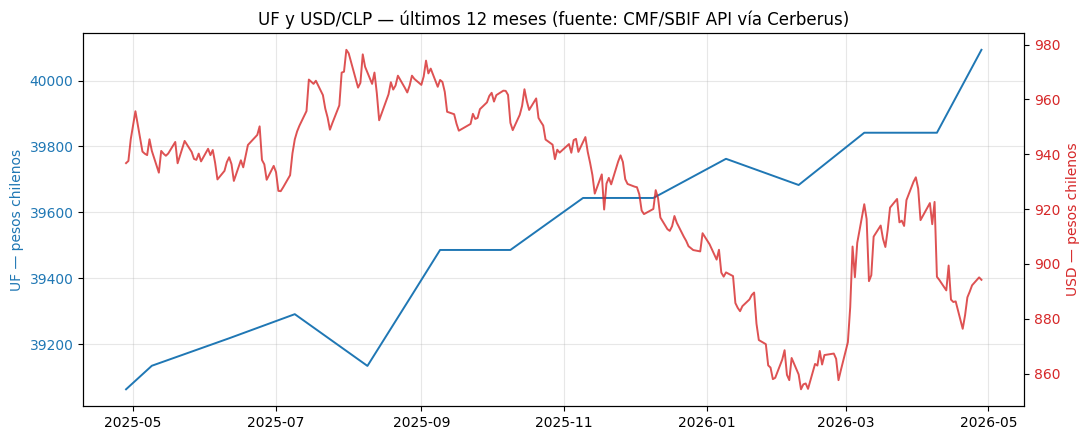


Var UF YoY  : +2.64%  (≈ inflación 12m)
Var USD YoY : -4.54%


In [16]:
# Gráfico dual UF + USD a 12 meses
df_uf  = pd.DataFrame(uf_hist).assign(date=lambda d: pd.to_datetime(d["date"]),
                                       value=lambda d: pd.to_numeric(d["value"]))
df_usd = pd.DataFrame(usd_hist).assign(date=lambda d: pd.to_datetime(d["date"]),
                                        value=lambda d: pd.to_numeric(d["value"]))

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(df_uf["date"], df_uf["value"], color="#1f77b4", lw=1.4, label="UF (CLP)")
ax1.set_ylabel("UF — pesos chilenos", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_usd["date"], df_usd["value"], color="#d62728", lw=1.4, alpha=0.8, label="USD/CLP")
ax2.set_ylabel("USD — pesos chilenos", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

ax1.set_title("UF y USD/CLP — últimos 12 meses (fuente: CMF/SBIF API vía Cerberus)")
fig.tight_layout(); plt.show()

# Inflación implícita en la UF (proxy)
uf_yoy = (df_uf["value"].iloc[-1] / df_uf["value"].iloc[0] - 1) * 100
usd_yoy = (df_usd["value"].iloc[-1] / df_usd["value"].iloc[0] - 1) * 100
print(f"\nVar UF YoY  : {uf_yoy:+.2f}%  (≈ inflación 12m)")
print(f"Var USD YoY : {usd_yoy:+.2f}%")


## 7 · ESG · NCG 461 — perfil del emisor + ranking sectorial

NCG 461 es la norma chilena que obliga a los emisores listados a reportar
indicadores ESG anuales. Cerberus expone:
- `esg.get(rut)` — todos los indicadores reportados por un emisor (todos los años)
- `esg.rankings(indicator=..., year=...)` — top-N por indicador en un año fiscal


In [17]:
esg_profile = client.esg.get(rut="91041000-8")  # Viña San Pedro Tarapacá
print(f"emisor : {esg_profile['emisor_nombre']} ({esg_profile['emisor_rut']})")
print(f"total indicadores reportados: {esg_profile['total_indicators']}")
print()
print(f"años con reportería:")
for y in esg_profile["years"][:3]:
    n = len(y["indicators"])
    print(f"  FY{y['fiscal_year']} : {n} indicadores")


emisor : VIÑA SAN PEDRO TARAPACA S.A. (91041000-8)
total indicadores reportados: 1711

años con reportería:
  FY2024 : 1711 indicadores


In [18]:
# Tomamos un indicator_code real del perfil y rankeamos top-10 emisores
indicator_code = esg_profile["years"][0]["indicators"][0]["indicator_code"]
print(f"Ranking top-10 — indicator_code = {indicator_code} (FY 2024)\n")

ranking = client.esg.rankings(indicator=indicator_code, year=2024, top_n=10, direction="desc")
df_rank = pd.DataFrame(ranking["rankings"])
df_rank["value"] = pd.to_numeric(df_rank["value"], errors="coerce")
df_rank


Ranking top-10 — indicator_code = bs.3.2.6.0465214232 (FY 2024)



,rank,emisor_rut,emisor_nombre,value,industry
0,1,91237000-3,FERIA DE OSORNO S.A.,1.61,None
1,2,91237000-3,FERIA DE OSORNO S.A.,1.61,None
2,3,91237000-3,FERIA DE OSORNO S.A.,1.61,None
3,4,91297000-0,CAP S.A.,1.18,None
4,5,91297000-0,CAP S.A.,1.18,None
5,6,91297000-0,CAP S.A.,1.18,None
6,7,91144000-8,EMBOTELLADORA ANDINA S.A.,1.11,None
7,8,91144000-8,EMBOTELLADORA ANDINA S.A.,1.11,None
8,9,91144000-8,EMBOTELLADORA ANDINA S.A.,1.11,None
9,10,76000739-0,ESVAL S.A.,1.00,None


## 8 · Catálogo SASB — taxonomía de materialidad por industria

SASB Standards 2023-12 codifica los temas materiales por industria. Cerberus
los expone en `/v1/sasb-topics` para cruzar con los indicadores ESG declarados.


In [19]:
topics_resp = client.sasb_topics.list(limit=200)
df_t = pd.DataFrame(topics_resp["topics"])
print(f"Total temas SASB cargados (página): {len(df_t)}")
print()
print("Cobertura por industria (top 12):")
print(df_t["industry"].value_counts().head(12).to_string())


Total temas SASB cargados (página): 200

Cobertura por industria (top 12):
industry
Commercial Banks                         15
Agricultural Products                    12
Chemicals                                12
Insurance                                11
Airlines                                 10
Coal Operations                          10
Electric Utilities & Power Generators    10
Health Care Delivery                     10
Home Builders                            10
Investment Banking & Brokerage           10
Apparel, Accessories & Footwear           9
Asset Management & Custody Activities     9


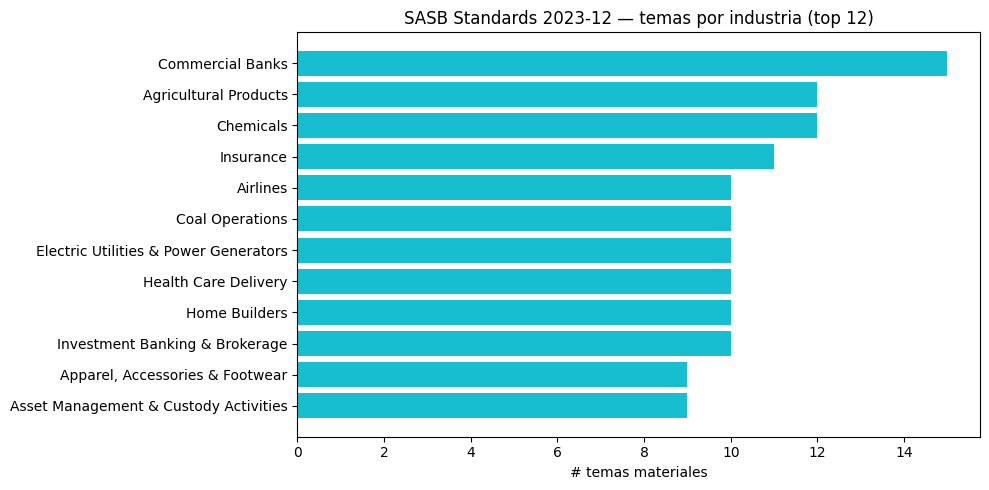

In [20]:
# Distribución de temas por industria — top 12
top_inds = df_t["industry"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_inds.index[::-1], top_inds.values[::-1], color="#17becf")
ax.set_xlabel("# temas materiales")
ax.set_title("SASB Standards 2023-12 — temas por industria (top 12)")
plt.tight_layout(); plt.show()


## 9 · Normativa y regulaciones — list + búsqueda full-text

Dos puntas:
- `regulations.list(limit=…)` — lista canonicalizada de NCG/circulares
- `regulations.search(q=…)` — full-text con `rank` BM25


In [21]:
regs = client.regulations.list(limit=8)
df_r = pd.DataFrame(regs)[["type", "ncg_number", "circular_number", "estado", "title", "issued_at"]]
df_r["title"] = df_r["title"].str.slice(0, 70)
df_r


,type,ncg_number,circular_number,estado,title,issued_at
0,ncg,NaN,None,desconocido,NCG 452,NaN
1,ncg,NaN,None,desconocido,NCG 461,NaN
2,ncg,NaN,None,desconocido,NCG 386,NaN
3,ncg,564.0,None,desconocido,MODIFICA NORMA DE CARÁCTER GENERAL N°550.,2026-04-20T00:00:00Z
4,ncg,562.0,None,vigente,ESTABLECE NORMA SOBRE REQUISITOS DE PATRIMONIO...,2026-04-20T00:00:00Z
5,ncg,563.0,None,desconocido,MODIFICA NORMA DE CARÁCTER GENERAL N°549.,2026-04-20T00:00:00Z
6,oficio,NaN,None,desconocido,COMUNICA NUEVO VALOR UNIDAD DE SEGURO REAJUSTA...,2026-04-14T00:00:00Z
7,oficio,NaN,None,desconocido,COMUNICA TASA DE INTERÉS DE ACTUALIZACIÓN - MA...,2026-04-14T00:00:00Z


In [22]:
# Búsqueda full-text — devuelve title + snippet + rank
hits = client.regulations.search(q="ciberseguridad operacional", limit=5)
for h in hits:
    print(f"rank={h['rank']:.3f}  {h['title'][:70]}")
    if h.get("snippet"):
        print(f"   → {h['snippet'][:140]}…")
    print()


rank=0.688  IMPARTE INSTRUCCIONES EN MATERIA DE GESTIÓN DE RIESGO OPERACIONAL Y CI
   → IMPARTE INSTRUCCIONES EN MATERIA DE GESTIÓN DE RIESGO OPERACIONAL Y CIBERSEGURIDAD, ASÍ COMO DE LA REALIZACÓN PERIÓDICA DE AUTOEVALUACIONES …

rank=0.327  NORMA QUE REGULA EL SISTEMA DE FINANZAS ABIERTAS.
   → NORMA QUE REGULA EL SISTEMA DE FINANZAS ABIERTAS.…

rank=0.268  REGULA EL REGISTRO,  AUTORIZACIÓN Y OBLIGACIONES DE LOS PRESTADORES DE
   → REGULA EL REGISTRO,  AUTORIZACIÓN Y OBLIGACIONES DE LOS PRESTADORES DE SERVICIOS FINANCIEROS DE LA  LEY FINTEC…

rank=0.167  INSTRUCCIONES SOBRE GESTIÓN DE RIESGO OPERACIONAL. DEROGA CIRCULARES N
   → INSTRUCCIONES SOBRE GESTIÓN DE RIESGO OPERACIONAL. DEROGA CIRCULARES N° 1.939 Y 2.020, Y LA NORMA DE CARÁCTER GENERAL N° 256. MODIFICA LA NO…

rank=0.125  IMPARTE INSTRUCCIONES SOBRE GOBIERNO CORPORATIVO Y GESTIÓN INTEGRAL DE
   → IMPARTE INSTRUCCIONES SOBRE GOBIERNO CORPORATIVO Y GESTIÓN INTEGRAL DE RIESGOS PARA CORREDORES DE BOLSA DE VALORES, AGENTES DE VAL

## 10 · Cross-reference contra listas internacionales

`sanctions.cross_reference(name|rut)` matchea la entidad/persona contra:
**OFAC SDN** · **UN Consolidated** · **EU/UK** · **CMF interno**.
Devuelve fuzzy matches sobre un threshold configurable (default 0.92).


In [23]:
xr = client.sanctions.cross_reference(name="Banco de Chile", threshold=0.5, limit=15)
df_xr = pd.DataFrame(xr["matches"])
print(f"Matches sobre threshold 0.5: {len(df_xr)}")
print(f"Distribución por fuente:")
print(df_xr["source"].value_counts().to_string())
print()
df_xr[["source", "name", "type", "score", "programs", "rut"]].sort_values("score", ascending=False).head(10)


Matches sobre threshold 0.5: 15
Distribución por fuente:
source
ofac_sdn    14
cmf          1



,source,name,type,score,programs,rut
0,cmf,BANCO SANTANDER CHILE,individual,0.9333,[],97.036.000-K
1,ofac_sdn,BANCO DE VENEZUELA SA BANCO UNIVERSAL,entity,0.8612,[VENEZUELA-EO13850],NaN
2,ofac_sdn,BANCO CORPORATIVO SA,entity,0.8571,[NICARAGUA],NaN
3,ofac_sdn,BANEH,vessel,0.8500,[IRAN],NaN
4,ofac_sdn,BANCO DE DESARROLLO ECONOMICO Y SOCIAL DE VENE...,entity,0.8476,[VENEZUELA-EO13850],NaN
5,ofac_sdn,BANCO PRODEM S.A.,entity,0.8345,[VENEZUELA-EO13850],NaN
6,ofac_sdn,BANCO NACIONAL DE CUBA,entity,0.8305,[CUBA],NaN
7,ofac_sdn,BANCO CENTRAL DE VENEZUELA,entity,0.8304,[VENEZUELA-EO13850],NaN
8,ofac_sdn,"BANCO BICENTENARIO DEL PUEBLO, DE LA CLASE OBR...",entity,0.8292,[VENEZUELA-EO13850],NaN
9,ofac_sdn,"BANCO INTERNACIONAL DE DESARROLLO, C.A.",entity,0.8216,"[IFSR, SDGT]",NaN


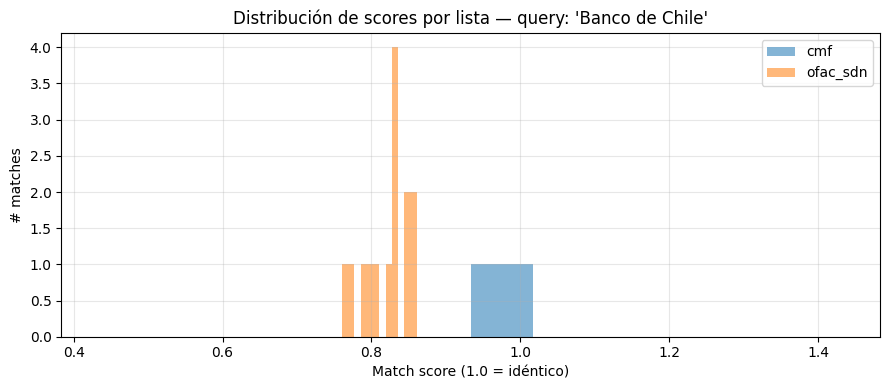

In [24]:
# Histograma de scores por fuente
fig, ax = plt.subplots(figsize=(9, 4))
for src, color in zip(df_xr["source"].unique(), ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]):
    subset = df_xr[df_xr["source"] == src]["score"]
    ax.hist(subset, bins=12, alpha=0.55, label=src, color=color)
ax.set_xlabel("Match score (1.0 = idéntico)")
ax.set_ylabel("# matches")
ax.set_title("Distribución de scores por lista — query: 'Banco de Chile'")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 11 · Webhooks — ciclo de vida + verificación HMAC offline

Cerberus puede empujar eventos (`entity.directors_changed`, `entity.sanctions_added`,
etc.) a una URL del cliente. Cada delivery se firma con HMAC-SHA256 sobre el body
crudo, usando un secret que el server entrega **una sola vez** al crear el webhook.

Demostramos el ciclo completo: **create → list → test → verify_signature → delete**.
La verificación se hace 100% offline (no requiere network).


In [25]:
# 1) CREATE — el server devuelve el secret en plaintext UNA SOLA VEZ.
# event_types está tipado contra WebhookEventType (Literal de los 11
# eventos válidos): mypy/pyright atajan strings inválidos en compile time.
from cerberus_compliance import WebhookEventType  # noqa: F401  (tipo, no usado en runtime)

created = client.webhooks.create(
    callback_url="https://hooks.tudominio.cl/cerberus-grand-tour",
    event_types=["sancion.new", "entity.changed"],
)
webhook_id = created["id"]
secret     = created["secret"]
print(f"webhook_id : {webhook_id}")
print(f"secret     : {secret[:12]}…  ← guardalo, no se puede recuperar")
print(f"status     : {created.get('status')}")
print(f"events     : {created.get('event_types')}")


webhook_id : 3c1e2b52-948a-4fd7-8a33-a37a2ec59677
secret     : whk_secret_p…  ← guardalo, no se puede recuperar
status     : active
events     : ['sancion.new', 'entity.changed']


In [26]:
# 2) VERIFY — simulamos cómo Cerberus firma deliveries (formato Stripe)
import hmac, hashlib, time

fake_body = json.dumps({
    "event": "sancion.new",
    "entity_rut": "97004000-5",
    "cmf_resolucion_id": "9999",
    "fecha_resolucion": "2026-04-28",
    "infraccion": "Demo payload — no es una sanción real",
}).encode()

# El header se firma sobre 'timestamp.payload' (estilo Stripe-compatible):
ts = int(time.time())
signed_payload = f"{ts}.".encode() + fake_body
mac = hmac.new(secret.encode(), signed_payload, hashlib.sha256).hexdigest()
sig_header = f"t={ts},v1={mac}"

# Y esto lo verificás en tu webhook handler:
ok = client.webhooks.verify_signature(
    payload=fake_body,
    signature_header=sig_header,
    secret=secret,
)
print(f"signature válida?    → {ok}")

# Por contraste, header manipulado o expirado:
bad_sig = client.webhooks.verify_signature(
    payload=fake_body,
    signature_header=f"t={ts},v1={'0' * 64}",
    secret=secret,
)
print(f"signature alterada?  → {bad_sig}  (debe ser False)")

old_sig = client.webhooks.verify_signature(
    payload=fake_body,
    signature_header=f"t={ts - 3600},v1={mac}",  # 1h atrás
    secret=secret,
    max_age_seconds=300,
)
print(f"signature expirada?  → {old_sig}  (debe ser False · max_age=5min)")


signature válida?    → True
signature alterada?  → False  (debe ser False)
signature expirada?  → False  (debe ser False · max_age=5min)


In [27]:
# 3) LIST — confirmamos que está registrado
listed = client.webhooks.list()
print(f"Webhooks activos: {listed['total']}")
for wh in listed["webhooks"]:
    print(f"  {wh['id']}  →  {wh['callback_url']}  events={len(wh.get('event_types', []))}")


Webhooks activos: 2
  3c1e2b52-948a-4fd7-8a33-a37a2ec59677  →  https://hooks.tudominio.cl/cerberus-grand-tour  events=2
  d84b6ca0-7cfb-4392-a4e8-0065aaa0f3ff  →  https://hooks.tudominio.cl/cerberus-grand-tour  events=2


In [28]:
# 4) DELETE — limpieza para no dejar webhooks colgados
client.webhooks.delete(webhook_id)
print(f"webhook {webhook_id} eliminado")
print(f"webhooks restantes: {client.webhooks.list()['total']}")


webhook 3c1e2b52-948a-4fd7-8a33-a37a2ec59677 eliminado


webhooks restantes: 1


## 12 · Exports asincrónicos — recursos completos en CSV/Parquet

Cuando se necesita TODA una colección (entities, sanctions, regulations…),
`/v1/exports` arma un job asíncrono y entrega un signed URL al S3 cuando
está listo. Aquí enumeramos los exports recientes generados por la org —
**no creamos uno nuevo** para no consumir cuota gratuitamente.


In [29]:
ex = client.exports.list(limit=10)
df_ex = pd.DataFrame(ex["items"])
df_ex["created_at"] = pd.to_datetime(df_ex["created_at"])
df_ex["expires_at"] = pd.to_datetime(df_ex["expires_at"])
df_ex[["resource", "format", "status", "rows_exported", "bytes_exported", "created_at"]]


,resource,format,status,rows_exported,bytes_exported,created_at
0,entities,parquet,ready,36.0,7450.0,2026-04-27 18:24:50.647915+00:00
1,entities,csv,ready,36.0,9588.0,2026-04-27 18:24:50.506439+00:00
2,entities,parquet,ready,36.0,7450.0,2026-04-27 17:35:08.080976+00:00
3,entities,csv,ready,36.0,9588.0,2026-04-27 17:35:07.950728+00:00
4,entities,parquet,ready,36.0,7450.0,2026-04-27 17:19:15.612653+00:00
5,entities,csv,ready,36.0,9588.0,2026-04-27 17:19:15.557159+00:00
6,entities,parquet,ready,36.0,7450.0,2026-04-27 17:13:31.490425+00:00
7,entities,csv,ready,36.0,9588.0,2026-04-27 17:13:31.355573+00:00
8,entities,parquet,ready,36.0,7450.0,2026-04-27 16:50:11.759722+00:00
9,entities,csv,ready,36.0,9588.0,2026-04-27 16:50:11.660474+00:00


## 13 · Paginación cursorada con `iter_all` — N entidades sin if-else

Los endpoints colección retornan un `next_cursor`. Los métodos `iter_all` del SDK
encapsulan ese loop: te devuelven un iterador que tira páginas a demanda hasta
que el server indica fin. Aquí tomamos las primeras 30 entidades.


In [30]:
from itertools import islice

count = 0
sample_rows = []
for ent in islice(client.entities.iter_all(), 30):
    count += 1
    if count <= 8:
        sample_rows.append({
            "rut": ent.get("rut"),
            "legal_name": (ent.get("legal_name") or "")[:50],
            "kind": ent.get("kind"),
            "status": ent.get("status"),
            "lei": ent.get("lei") or "—",
        })

print(f"Iteradas: {count} entidades (con paginación interna automática)")
pd.DataFrame(sample_rows)


Iteradas: 30 entidades (con paginación interna automática)


,rut,legal_name,kind,status,lei
0,99518380-3,CRUZ DEL SUR ADMINISTRADORA GENERAL DE FONDOS ...,administradora_cartera,no_vigente,—
1,79516570-3,ITAU BBA CORREDOR DE BOLSA LIMITADA,administradora_cartera,no_vigente,—
2,76613788-1,PATAGON LAND ADMINISTRADORA GENERAL DE FONDOS ...,administradora_cartera,no_vigente,—
3,99580930-3,ZURICH ADMINISTRADORA GENERAL DE FONDOS S.A.,administradora_cartera,no_vigente,—
4,99558780-7,PENTA ADMINISTRADORA GENERAL DE FONDOS S.A.,administradora_cartera,no_vigente,—
5,76416012-6,VISION GLOBAL INVESTMENTS S.A.,administradora_cartera,no_vigente,—
6,76576607-9,SARTOR ADMINISTRADORA GENERAL DE FONDOS S.A.,administradora_cartera,no_vigente,254900WFJ4M5N1L2ED61
7,96815680-2,SCOTIA AZUL ASSET MANAGEMENT ADMINISTRADORA GE...,administradora_cartera,no_vigente,—


## 14 · Dashboard final · 4 cuadrantes

Combinamos todo lo recolectado en un dashboard 2×2:
1. Risk score del portfolio · 2. UF (12m) · 3. Sanciones por mes · 4. Cross-ref Banco de Chile.


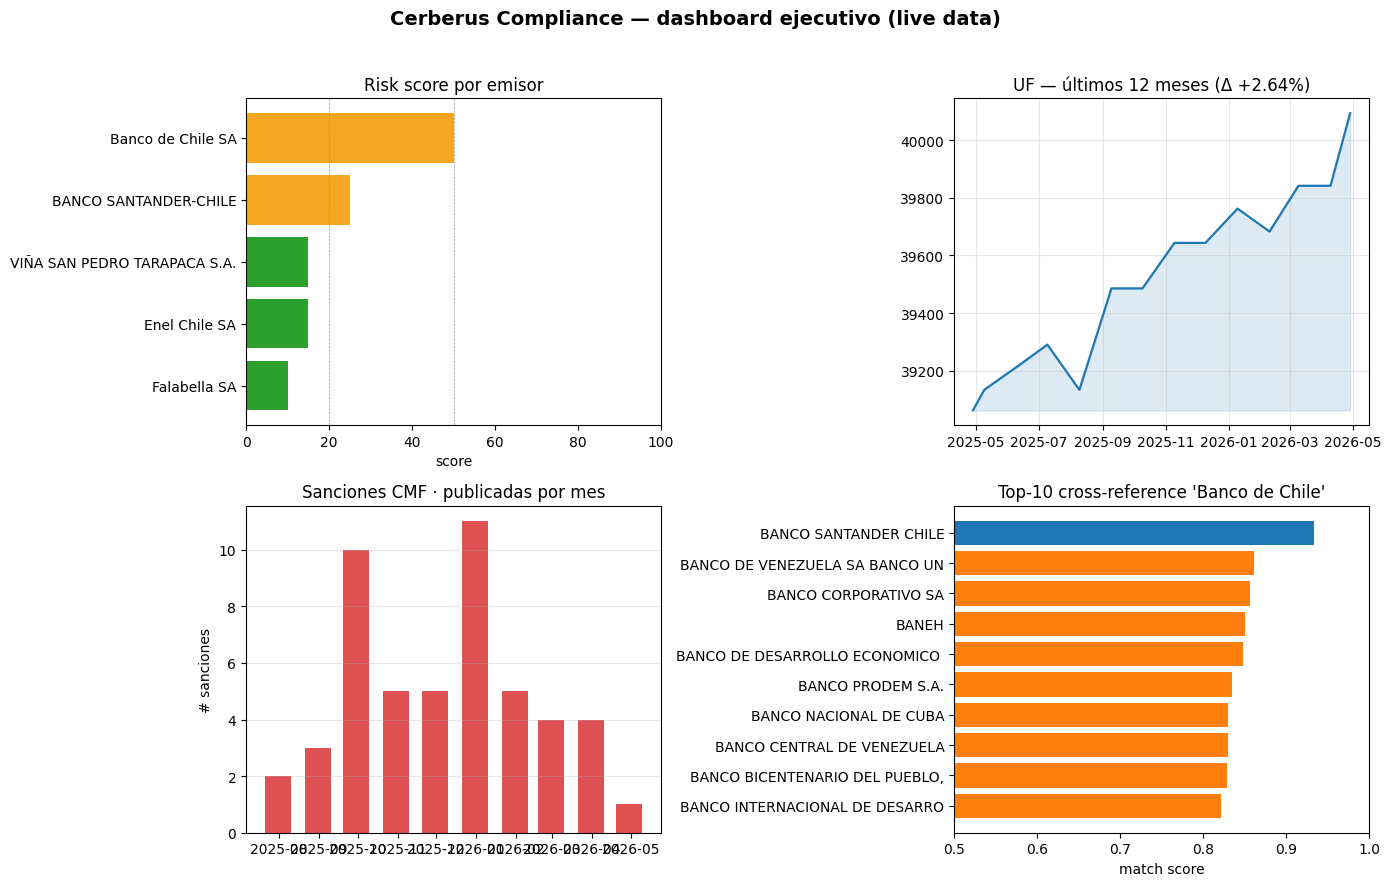

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Cerberus Compliance — dashboard ejecutivo (live data)", fontsize=14, weight="bold")

# (1) Risk score del portfolio
ax = axes[0, 0]
ax.barh(portfolio_ok["legal_name"], portfolio_ok["risk_score"],
        color=[_color(s) for s in portfolio_ok["risk_score"]])
ax.set_xlim(0, 100); ax.set_title("Risk score por emisor"); ax.set_xlabel("score")
ax.axvline(20, color="#999", lw=0.5, ls="--"); ax.axvline(50, color="#999", lw=0.5, ls="--")

# (2) UF 12 meses
ax = axes[0, 1]
ax.plot(df_uf["date"], df_uf["value"], color="#1f77b4", lw=1.6)
ax.fill_between(df_uf["date"], df_uf["value"].min(), df_uf["value"], alpha=0.15, color="#1f77b4")
ax.set_title(f"UF — últimos 12 meses (Δ {uf_yoy:+.2f}%)")
ax.grid(alpha=0.3)

# (3) Sanciones por mes
ax = axes[1, 0]
ax.bar(monthly.index, monthly.values, width=20, color="#d62728", alpha=0.8)
ax.set_title("Sanciones CMF · publicadas por mes"); ax.set_ylabel("# sanciones")
ax.grid(axis="y", alpha=0.3)

# (4) Cross-ref top-10 por score
ax = axes[1, 1]
top_xr = df_xr.sort_values("score", ascending=True).tail(10)
colors = {"cmf": "#1f77b4", "ofac_sdn": "#ff7f0e", "un": "#2ca02c", "eu": "#9467bd", "uk": "#8c564b"}
ax.barh(top_xr["name"].str.slice(0, 30), top_xr["score"],
        color=[colors.get(s, "#999") for s in top_xr["source"]])
ax.set_xlim(0.5, 1.0)
ax.set_title("Top-10 cross-reference 'Banco de Chile'")
ax.set_xlabel("match score")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 15 · Resumen — endpoints ejercitados

| # | Recurso SDK | Endpoint | Demo |
|---|---|---|---|
| 1 | `admin_api_keys.me()` | `/admin/api-keys/me` | Introspección key |
| 2 | `kyb.get(rut, include=…)` | `/kyb/{rut}` | Perfil agregado Banco de Chile |
| 3 | `AsyncCerberusClient` + `kyb.get` | (×6 paralelas) | Portfolio scan |
| 4 | `sanctions.list()` | `/sanctions` | 50 sanciones recientes |
| 5 | `search.search(filters=SearchFilters(...))` | `/search` | Semántica cross-tipo |
| 6 | `indicadores.get` + `indicadores.history(from_, to)` | `/indicadores/{name}` | UF/USD/UTM/IPC |
| 7 | `esg.get` + `esg.rankings` | `/esg/by-rut`, `/esg/rankings` | NCG 461 |
| 8 | `sasb_topics.list` | `/sasb-topics` | Taxonomía SASB |
| 9 | `regulations.list` + `.search` | `/regulations`, `/regulations/search` | Full-text |
| 10 | `sanctions.cross_reference` | `/sanctions/cross-reference` | OFAC/UN/EU/CMF |
| 11 | `webhooks.create/list/delete` + `verify_signature` | `/webhooks` | Lifecycle + HMAC |
| 12 | `exports.list` | `/exports` | Jobs históricos |
| 13 | `entities.iter_all()` | `/entities?cursor=…` | Paginación cursorada |

**13 puntos de la API · 1 notebook · 0 frameworks adicionales más allá de pandas+matplotlib.**

### Cleanup

Cerramos el cliente síncrono — el async ya se cerró con su `async with`.


In [32]:
client.close()
print("client cerrado · cuota residual:", client.admin_api_keys if False else "(consultar de nuevo si querés ver consumo)")


client cerrado · cuota residual: (consultar de nuevo si querés ver consumo)


---

**Notas de operación:**
- Las multas en UF llegan como string (`Decimal` en server) — convertir explícitamente antes de agregaciones.
- `kyb.get` con `as_of=date(...)` da snapshots point-in-time (útil para diligencia retroactiva).
- Para OPS productiva: setear `RetryConfig(max_attempts=8, max_total_seconds=120)` al instanciar el cliente, y montar logging estructurado.
- SDK ≥ 0.6.0 alinea Search/Indicadores/Webhooks con el contrato live; antes de esa versión hay drift que requería workarounds vía `client._request()`.

🐍🔱 Generado por: Cerberus SDK Grand Tour · 2026-04-28
